<a href="https://colab.research.google.com/github/jfbadarom/Fisica-com-Python/blob/main/Tarefa_2_Jo%C3%A3o_Felipe.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

>>>  
Tarefas práticas




#Tarefa 2

Colocar no github

##Q1

Para entender o Método de Monte Carlo (MMC), *reproduza* os exemplos deste [tutorial](https://youtu.be/vNWTRsBFmUw?si=5_bsqCWXVeXh4CUx):


*Aprimore* a análise de convergência usando gráficos de  [boxplot concatenados lado a lado](https://youtu.be/BFpbchNlIeg?si=M-rxC7cUXAyniQZ8) para diferentes tamanhos de amostras.


OBS: Em todos os casos, adicione comentários com uma discussão que explique os gráficos gerados.



In [ ]:
import random
import matplotlib.pyplot as plt
import math
import numpy as np

Número de Pontos dentro:  784
Número de Pontos fora:  1000
Valor simulado de Pi:  3.136
Valor de exato de Pi:  3.141592653589793
Erro do método:  -0.005592653589792995
Precisão:  99.4407346410207


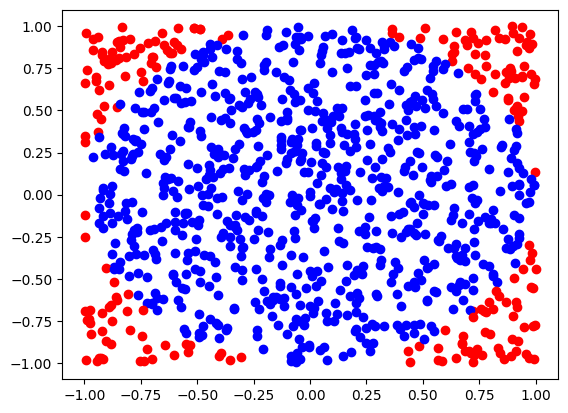

In [ ]:
N=1000
n_in=0
c=0
fig, ax = plt.subplots()
while (c<N):
  x=2*random.random()-1
  y=2*random.random()-1
  z=x**2+y**2
  if (z<=1):
    n_in+=1
    ax.plot(x,y,'o', color='blue')
  else:
    ax.plot(x,y,'o', color='red')
  c+=1
pi_mc=4*n_in/N
print("Número de Pontos dentro: ", n_in)
print("Número de Pontos fora: ", N)
print("Valor simulado de Pi: ", pi_mc)
print("Valor de exato de Pi: ", math.pi)
print("Erro do método: ", (pi_mc-math.pi))
print("Precisão: ", 100*(1-abs(pi_mc-math.pi)))
plt.show()


In [ ]:
def PIMC(N, plot=False, verbose=True):
  if plot:
    fig, ax = plt.subplots()
  n_in=0
  c=0
  while (c<N):
    x=2*random.random()-1
    y=2*random.random()-1
    z=x**2+y**2
    if (z<=1):
      n_in+=1
      if plot:
        ax.plot(x,y,'o', color='blue')
    else:
      if plot:
        ax.plot(x,y,'o', color='red')
    c+=1
  pi_mc=4*n_in/N
  if verbose:
    print("Número de Pontos dentro: ", n_in)
    print("Número de Pontos fora: ", N)
    print("Valor simulado de Pi: ", pi_mc)
    print("Valor de exato de Pi: ", math.pi)
    print("Erro do método: ", (pi_mc-math.pi))
    print("Precisão: ", 100*(1-abs(pi_mc-math.pi)))
  plt.show()
  return pi_mc



Número de Pontos dentro:  7817
Número de Pontos fora:  10000
Valor simulado de Pi:  3.1268
Valor de exato de Pi:  3.141592653589793
Erro do método:  -0.014792653589793314
Precisão:  98.52073464102067


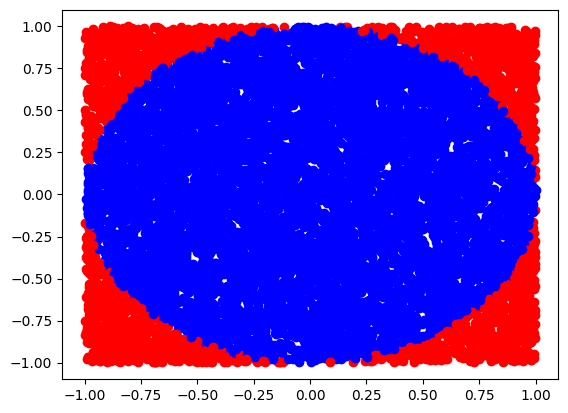

In [ ]:
PIMC(10000,plot=True)

Dessa forma é possível calcular o número π com uma certa precisão que é proporcional ao valor total de pontos.

In [ ]:
import pandas as pd

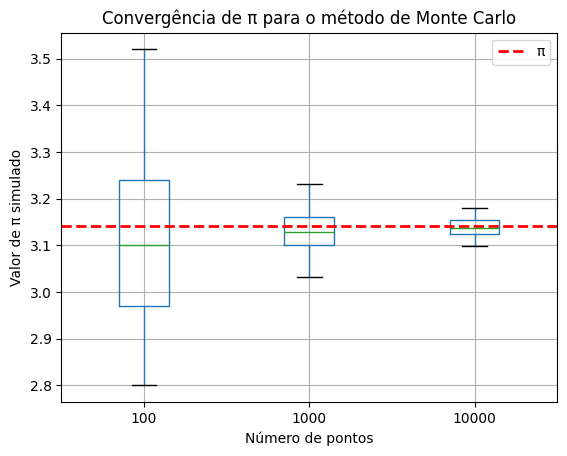

In [ ]:
M=50#Número de realizações do MC
N=[100,1000,10000]
data={}
for i in N:
  data[i]=[]
  for j in range(M):
    pivalue=PIMC(i,verbose=False)
    data[i].append(pivalue)
df=pd.DataFrame(data)
bloxplot=df.boxplot()
plt.axhline(y=math.pi, color='red', linestyle='--', linewidth=2, label="π")
plt.legend()
plt.title("Convergência de π para o método de Monte Carlo")
plt.xlabel("Número de pontos")
plt.ylabel("Valor de π simulado")
plt.show()

Usando o gráfico de boxplot é possível perceber claramente a convergência dos valores simulados para monte carlo para o valor de π. O os valores máximos e minimos bem como os primeiros e terceiros quartis vão convergindoao valor de π

Sobre o método de Monte Carlo para estimar π:

* (a) Reobtenha os resultados mostrados na Fig.1 do  artigo de [Strbac-Savic, Miletic, Stefanović 2015](https://www.researchgate.net/profile/Ana-Miletic-2/publication/282909462_The_estimation_of_Pi_using_Monte_Carlo_technique_with_interactive_animations/links/56b34b8008ae3d06a2664232/The-estimation-of-Pi-using-Monte-Carlo-technique-with-interactive-animations.pdf). Para auxiliar use o matplotlib. Coloque no título de cada painel o valor da estimativa de π.
*  (b) Faça uma organização tabular dos resultados anteriores similar a tabela 1 do artigo de [Sharma, Singhal, Agrawal 2021](https://iopscience.iop.org/article/10.1088/1757-899X/1116/1/012130/meta). Para auxiliar use o pandas.


Começando pelo item (a)

In [ ]:

def PIMC2(N):
  x = 2*np.random.rand(N)-1 #Vetores de números aleátórios
  y = 2*np.random.rand(N)-1
  dentro = x**2+y**2 <=1 #Verificando se está dentro ou fora do circulo de raio unitário
  fora = x**2+y**2 >1
  return x, y, dentro, fora


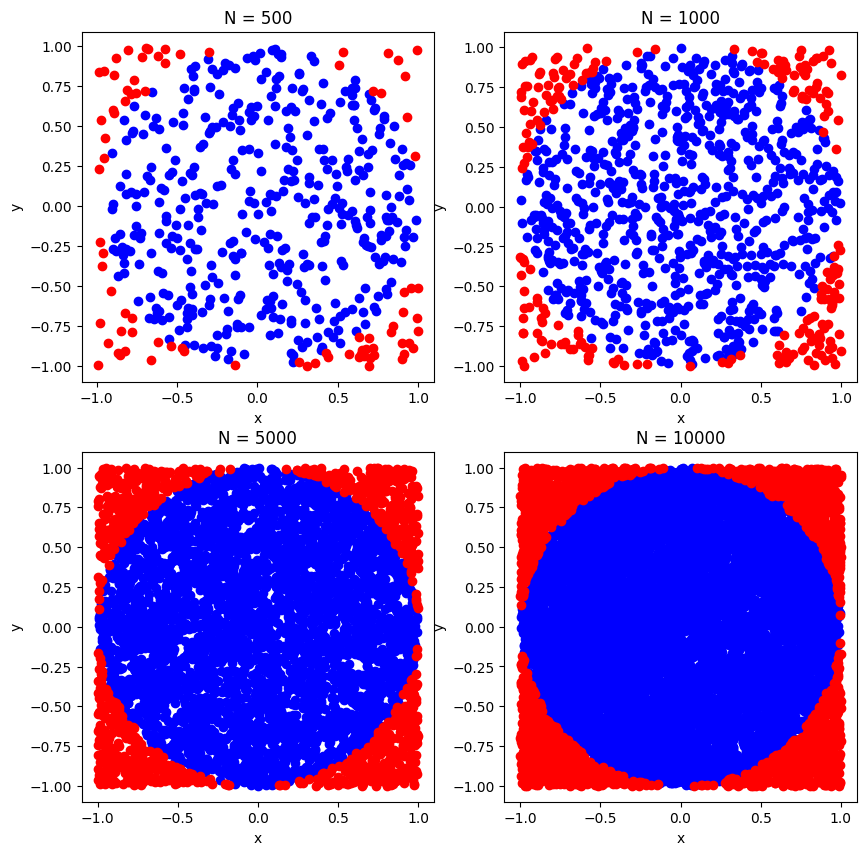

In [ ]:
N=[500,1000,5000,10000]
fig, ax = plt.subplots(2, 2, figsize=(10, 10)) #Grade de gráficos
for i,j in enumerate(N):
  x, y, dentro, fora = PIMC2(j)
  ax[i//2, i%2].scatter(x[dentro], y[dentro], color='blue', label='Dentro')#Pontos Azuis se dentro é verdadeiro
  ax[i//2, i%2].scatter(x[fora], y[fora], color='red', label='Fora')#Pontos Azuis se fora é verdadeiro
  ax[i//2, i%2].set_title(f'N = {j}')
  ax[i//2, i%2].set_xlabel('x')
  ax[i//2, i%2].set_ylabel('y')
plt.show()

Item (b)

In [ ]:
N=[500,1000,5000,10000]
data={}
for j in N:
  data[j]=[]
  x, y, dentro, fora = PIMC2(j)
  M=sum(dentro)
  pi_mc=4*M/(j)
  data[j].append(int(M))
  data[j].append(pi_mc)
  data[j].append(pi_mc-math.pi)
  data[j].append(100*(abs(pi_mc-math.pi)))
data=pd.DataFrame(data)
data.columns.name = 'Simulation runs (N)'
data.index = ['M', 'Value of Pi', 'Absolute error', '%Error']
layout = [
    # Estilo do Título (Caption)
    {'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold'), ('color', '#333333'), ('padding', '12px 0')]},
    # Estilo dos Cabeçalhos Superiores (Os valores de N)
    {'selector': 'th.col_heading', 'props': [('background-color', '#2c3e50'), ('color', 'white'), ('text-align', 'center'), ('font-size', '13px'), ('padding', '10px')]},
    # Estilo dos Cabeçalhos Laterais (Os nomes das suas linhas: M, Value of Pi, etc.)
    {'selector': 'th.row_heading', 'props': [('background-color', '#ecf0f1'), ('color', '#2c3e50'), ('text-align', 'left'), ('font-weight', 'bold'), ('padding', '10px')]},
    # Estilo das Células com os números
    {'selector': 'td', 'props': [('text-align', 'center'), ('padding', '10px'), ('border-bottom', '1px solid #dddddd')]},
    # Efeito visual ao passar o rato por cima da linha (Hover)
    {'selector': 'tr:hover', 'props': [('background-color', '#d9e2f3')]}
] #Aqui eu utilizei um layout qualquer de tabela que o gemini me gerou

fatia = pd.IndexSlice #Para retirar o arrendondamento do inteiro M
tabela = data.style \
    .format("{:.0f}", subset=fatia[['M'], :]) \
    .format("{:.4f}", subset=fatia[['Value of Pi', 'Absolute error', '%Error'], :]) \
    .set_caption("Análise de Erro na Estimativa de Pi (Método de Monte Carlo)") \
    .set_table_styles(layout)
tabela


Simulation runs (N),500,1000,5000,10000
M,393,798,3934,7846
Value of Pi,3.1440,3.1920,3.1472,3.1384
Absolute error,0.0024,0.0504,0.0056,-0.0032
%Error,0.2407,5.0407,0.5607,0.3193




>*Opcional*: Quem quiser se aprofundar pode consultar este outro [tutorial](https://youtu.be/rNOe62Z3zZg?si=KiNHd7sLJo5GczrW) que tem um nivel intermediário


## Q2

Primeiramente reproduza o código do vídeo [Método de Monte Carlo, Passeio aleatório e difusão](https://youtu.be/Rj9_fPLSMyc?si=K6P0JL9dJ6UOjv0f) no seu colab com os correspondentes gráficos relacionados ao passeio aleatório.

Em seguida adapte o referido código para obter:

*   A distribuição de probabilidade P(x,t) para
t=5 comparando com a distribuição binomial. t=500 comparando com a distribuição gaussiana. Discuta o **Teorema Central do Limite (TCL)**.  Faça em um painel 1x2.

*   A evolução temporal da média, variância, skewness e kurtosis. Faça em um painel 1x3 usando [plt.subplots(1, 3)](https://education.molssi.org/python-visualization/matplotlib/subplots.html). Você deve considerar t de 0 até $10^3$  e M trajetórias (ensemble) . Use $M=\{10, 10^2, 10^3\}$ e discuta a **Lei dos Grandes Números (LGN)**.

Em todos os casos adicione gráficos e faça a discussão com base na [Física da difusão](https://youtu.be/BLRH48ulbUQ?si=qyf0l6GbBIRTbt2U)  




In [ ]:
def randomwalk(x,t):
  Tl=[0]
  Xl=[0]
  for i in range(1,t+1):
    Tl.append(i)

    rand  = random.choice(x)
    step= Xl[i-1]+rand
    Xl.append(step)
  plt.plot(Tl,Xl)
  plt.xlabel('Time')
  plt.ylabel('Position')
  plt.show()


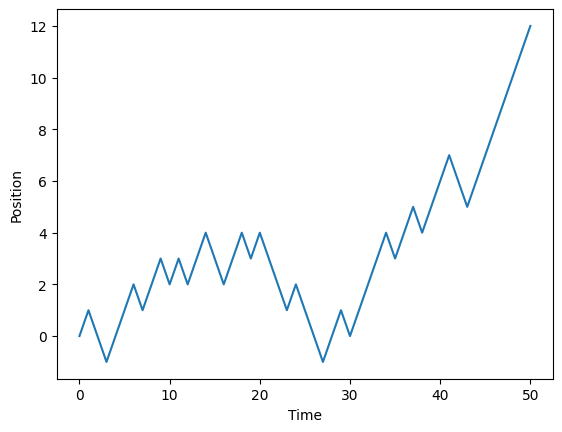

In [ ]:
randomwalk([-1,1],50)

Vamos considerar agora um ensemble de trajetórias

In [ ]:
def randomwalk2(x,t):
  Tl=[0]
  Xl=[0]
  for i in range(1,t+1):
    Tl.append(i)
    rand  = random.choice(x)
    step= Xl[i-1]+rand
    Xl.append(step)
  return Xl


In [ ]:
from scipy.stats import binom, norm

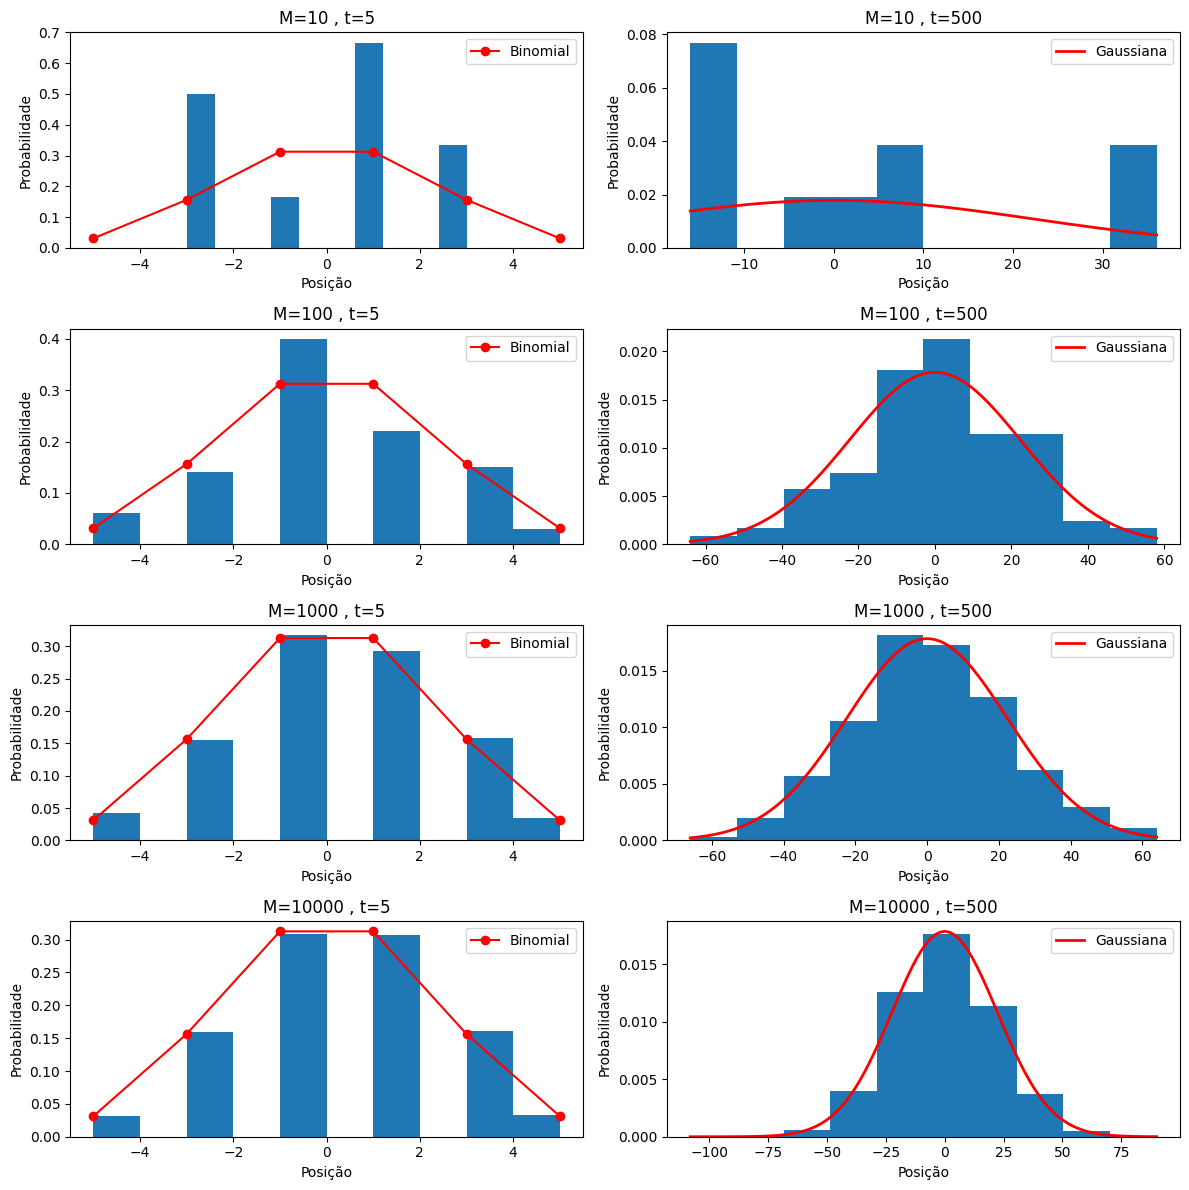

In [ ]:

T=[5, 500]
M=[10,100, 1000, 10000]
x=[-1,1]
fig, ax = plt.subplots(len(M), len(T),figsize=(12, 12))
lfx=[]
for i,t in enumerate(T):

  for j,m in enumerate(M):
    finalX=[]
    for k in range(m):
      finalX.append(randomwalk2(x,t)[-1])
    ax[j,i].hist(finalX, density= True)
    ax[j,i].set_xlabel("Posição")
    ax[j,i].set_ylabel("Probabilidade")
    ax[j,i].set_title(f"M={m} , t={t}")
    lfx.append(finalX)
    if t == 5:
      k_passos = np.arange(0, t + 1)
      posicoes_x = 2 * k_passos - t # Transforma passos (0 a 5) em posição (-5 a 5)
      prob_binomial = binom.pmf(k_passos, t, 0.5)
      ax[j,i].plot(posicoes_x, prob_binomial, 'ro-', label='Binomial')
      ax[j,i].legend()
    elif t == 500:
      eixo_x = np.linspace(min(finalX), max(finalX), 100)
      desvio_padrao = np.sqrt(t) # O desvio padrão na difusão é a raiz de t
      curva_gaussiana = norm.pdf(eixo_x, loc=0, scale=desvio_padrao)
      ax[j,i].plot(eixo_x, curva_gaussiana, 'r-', linewidth=2, label='Gaussiana')
      ax[j,i].legend()

plt.tight_layout()
plt.show()
plt.show()

É possível perceber que para tempos baixos a distribuição se aproxima de uma binomial enquanto que para tempos longos ela se aproxima de uma distribuição gaussiana. E quanto mais interações de monte carlo fazemos mais mais suave fica a curva e se aproxima cada vez mais do valor exato das distribuições.

In [ ]:
from scipy.stats import skew, kurtosis

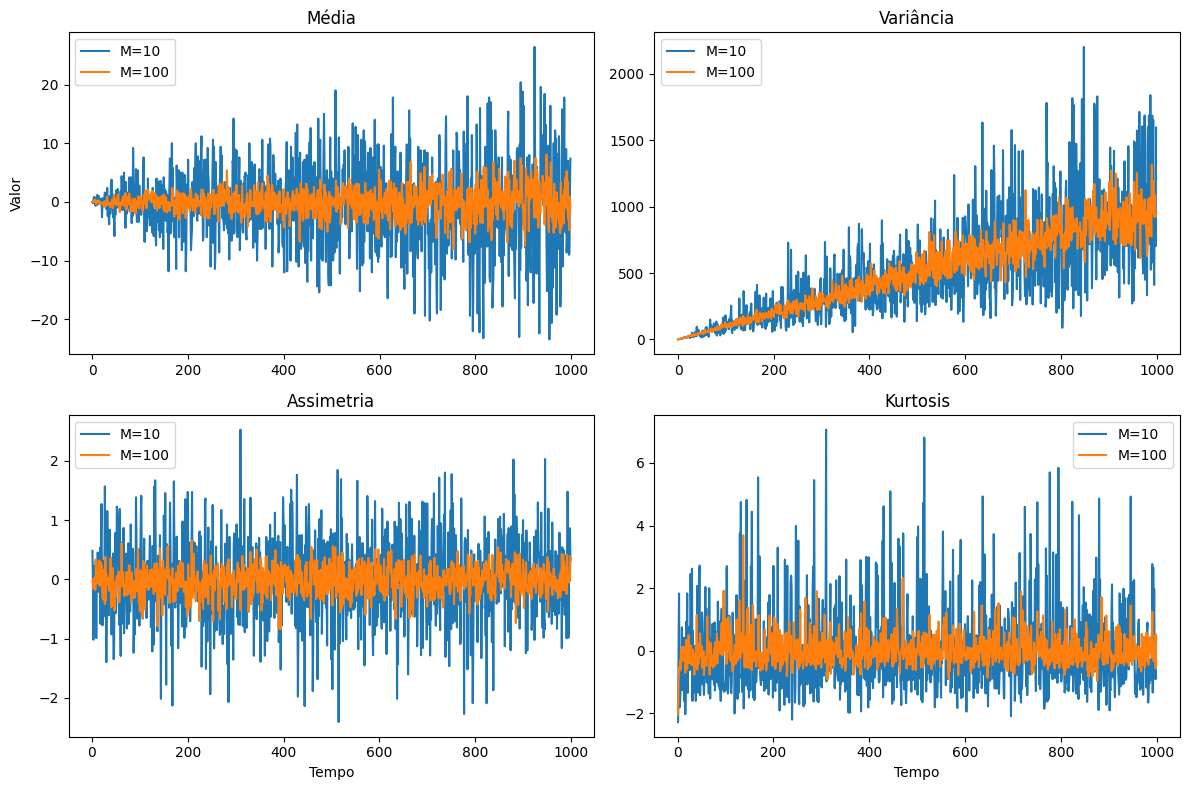

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis

T = np.arange(0, 1000)
M = [10, 100]
x = [-1, 1]

plt.figure(figsize=(12, 8))

# Invertemos a ordem: o loop de M fica por fora para plotar uma linha completa por vez
for j, m in enumerate(M):
    media = []
    variancia = []
    assimetria = []
    kurt = []

    for i, t in enumerate(T):
        finalX = []
        for k in range(m):
            finalX.append(randomwalk2(x, t)[-1])
        dados_finais = np.array(finalX)

        media.append(np.mean(dados_finais))
        variancia.append(np.var(dados_finais, ddof=1))
        assimetria.append(skew(dados_finais, bias=False))
        kurt.append(kurtosis(dados_finais, bias=False))

    # Plotando os dados deste 'm' nos 4 subgráficos diferentes
    plt.subplot(2, 2, 1)
    plt.plot(T, media, label=f'M={m}')

    plt.subplot(2, 2, 2)
    plt.plot(T, variancia, label=f'M={m}')

    plt.subplot(2, 2, 3)
    plt.plot(T, assimetria, label=f'M={m}')

    plt.subplot(2, 2, 4)
    plt.plot(T, kurt, label=f'M={m}')

# Configurando títulos e legendas para cada um dos 4 gráficos
plt.subplot(2, 2, 1)
plt.title('Média')
plt.ylabel('Valor')
plt.legend()

plt.subplot(2, 2, 2)
plt.title('Variância')
plt.legend()

plt.subplot(2, 2, 3)
plt.title('Assimetria')
plt.xlabel('Tempo')
plt.legend()

plt.subplot(2, 2, 4)
plt.title('Kurtosis')
plt.xlabel('Tempo')
plt.legend()

plt.tight_layout()
plt.show()

É possível novamente perceber que conforme aumentamos o número de simulações de montecarlo as distribuições do passeio passam a convergir para as distribuições que conhecemos.

##Q3

OPCIONAL:

Reobtenha o resultado da Figura 1a (superior à esquerda) da referência abaixo que introduz o **Lima-Curado Random Walk** (2026).
Faça uma discussão com uma tabela comparativa em relação ao random walk convecional.

[HS Lima, EMF Curado. Emergent heavy-tailed distributions from a Markovian random walk. arXiv, 2026](https://arxiv.org/abs/2605.22933).


Essa é uma simulação computacionalmente pesada, logo você precisará usar o pacote **numba**:
*   [Documentação](https://https://numba.pydata.org/numba-doc/dev/user/5minguide.html)
*   [Tutorial](https://www.youtube.com/watch?v=TnzXRAZaWGI)
